# TullockDynamics.jl
A brief and incomplete introduction to the `TullockDynamics.jl` package I created. First we need to load the package.

In [1]:
using Pkg; Pkg.activate("../TullockDynamics.jl")
using TullockDynamics

  Activating project at `~/github/TullockDynamics.jl`


## Set up agents

I'll first describe how to define a general agent by setting her parameters appropriately. It's possible to create contests with different kinds of agents, who have heterogeneous parameters.

In [2]:
linear_cost(x) = x  # agent has linear cost function
p(t) = 1  # agent plays in every round
window(t) = 1:t-1  # agent has access to full history
α(t) = 1  # agent commits fully to best response
δ = 0.05  # lower bound on agent's effort
estimator = max_likelihood_estimator;  # agent follows MLE mechanism

Now we can create an agent, or even a vector of agents, with these parameters. For simplicity, I'll create a vector of `n` homogeneous agents who all share the same parameters.

In [3]:
n = 3  # number of agents
a = Agent(linear_cost, p, window, α, estimator, δ)  # a single agents
agents = [Agent(linear_cost, p, window, α, estimator, δ) for _ in 1:n]  # a vector of agents
initial_efforts = [rand() for _ in 1:n];

My package also provides convenience constructors `MLEAgent`, `DetMLEAgent` and `DumbAgent` that set the above defaults for `p`, `window` and `α`, and choose the appropriate estimator. So we could have constructed the agents by writing:

In [4]:
# agents = [DetMLEAgent(linear_cost; δ = δ) for _ in 1:n];
agents = [MLEAgent(linear_cost; δ = δ) for _ in 1:n];
# agents = [DumbAgent(linear_cost; δ = δ) for _ in 1:n];

## Creating a Tullock contest
Now we create the contest using the agents defined above, and fixing the number of rounds `T`.

In [5]:
T = 2000
contest = TullockContest(agents, initial_efforts, T);

The `contest` object stores the progress of the Tullock contest in four matrices:
* `contest.efforts`
* `contest.utilities`
* `contest.nash_gaps`
* `contest.winners`

For any such matrix, the entry `matrix[i,t]` is the value for agent `i` in round `t`. We can see the final efforts of all the agents, e.g., as follows:

In [6]:
contest.efforts[:,T]

3-element Vector{Float64}:
 0.0
 0.0
 0.0

## Running the dynamic
Now we run the dynamic.

In [7]:
run!(contest)

Running contest


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


## Plotting the output

My package provides a convenience function to plot the efforts, utilities, Nash gaps, or winners by just passing the relevant matrix into the function. You also need to provide the y-axis range.

For example, we could plot efforts, utilities and Nash gaps like this:

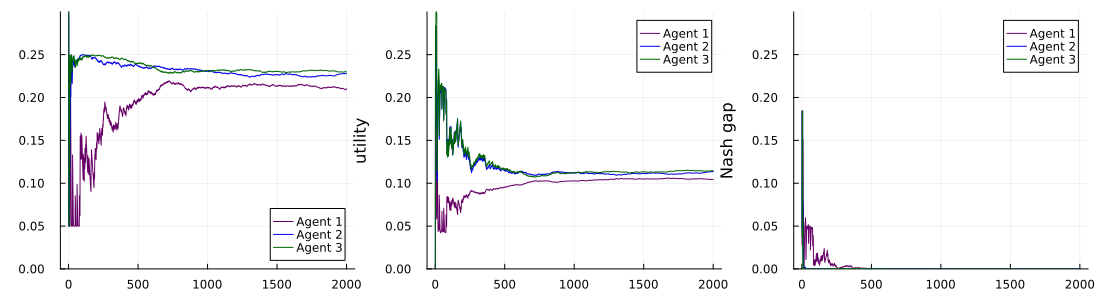

In [8]:
efforts_plt = plot(contest.efforts, ylims=(0,0.3), ylabel="effort")
util_plt = plot(contest.utilities, ylims=(0,0.3), ylabel="utility")
nash_plt = plot(contest.nash_gaps, ylims=(0,0.3), ylabel="Nash gap")
# combine all three plots into one, side by side
plot(efforts_plt, util_plt, nash_plt, layout=(1,3), size=(1100,300))

We can also look only at the efforts, in a larger plot:

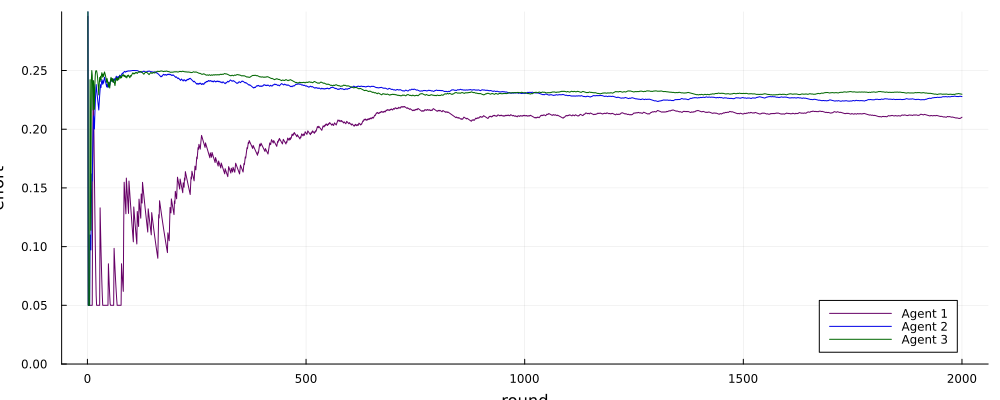

In [9]:
plot(efforts_plt, size=(1000,400))